# Đồ án 3: Tái thực nghiệm

In [30]:
%config InlineBackend.figure_format = 'svg'
import networkx as nx
import numpy as np
import scipy.linalg
import random
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
from scipy.optimize import linear_sum_assignment

# Thiết lập seed để kết quả ổn định
GLOBAL_SEED = 42
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)

In [2]:
def preprocess_paper_graph(filepath):
    G = nx.read_edgelist(filepath)
    
    largest_cc = max(nx.connected_components(G), key=len)
    S = nx.Graph(G.subgraph(largest_cc))
    
    # Xóa các node có degree < 10
    while True:
        nodes_to_remove = [node for node in S.nodes() if S.degree(node) < 10]
        if not nodes_to_remove:
            break
        S.remove_nodes_from(nodes_to_remove)
        largest_cc = max(nx.connected_components(S), key=len)
        S = nx.Graph(S.subgraph(largest_cc))
        
    # Loại bỏ các cụm nhỏ thông qua Minimum Edge Cut
    while True:
        cutset = nx.minimum_edge_cut(S)
        if len(cutset) > 10:
            break
        S.remove_edges_from(cutset)
        largest_cc = max(nx.connected_components(S), key=len)
        S = nx.Graph(S.subgraph(largest_cc))
        
    return nx.convert_node_labels_to_integers(S)

In [3]:
def spectral_clustering_sc2(G):
    # Ma trận Laplacian
    L = nx.laplacian_matrix(G).toarray().astype(float)
    
    # Tìm Vector riêng nhỏ thứ 2
    eigenvalues, eigenvectors = scipy.linalg.eigh(L)
    v2 = eigenvectors[:, 1]

    node_scores = [(node, v2[i]) for i, node in enumerate(G.nodes())]
    sorted_nodes = [node for node, score in sorted(node_scores, key=lambda x: x[1])]
    
    # Cắt
    best_ratio = float('inf')
    cluster_1 = []
    n = len(sorted_nodes)
    
    for i in range(1, n):
        S1 = sorted_nodes[:i]
        S2 = sorted_nodes[i:]
        cut_val = nx.cut_size(G, S1, S2)
        ratio = cut_val / (len(S1) * len(S2))
        
        if ratio < best_ratio:
            best_ratio = ratio
            cluster_1 = S1
            
    cluster_2 = [n for n in G.nodes() if n not in cluster_1]
    return set(cluster_1), set(cluster_2)

In [4]:
def get_d_size(c1_true, c2_true, c1_pred, c2_pred):
    """Tính d_size (Symmetric Difference)"""
    # Trường hợp 1: Cụm 1 khớp Cụm 1
    diff1 = len(c1_true.symmetric_difference(c1_pred)) + len(c2_true.symmetric_difference(c2_pred))
    # Trường hợp 2: Cụm 1 khớp Cụm 2 (đảo nhãn)
    diff2 = len(c1_true.symmetric_difference(c2_pred)) + len(c2_true.symmetric_difference(c1_pred))
    return min(diff1, diff2)

In [5]:
def apply_edge_flipping(G, p, seed):
    random.seed(seed)
    noisy_G = nx.Graph()
    noisy_G.add_nodes_from(G.nodes())
    nodes = list(G.nodes())
    for i in range(len(nodes)):
        for j in range(i+1, len(nodes)):
            u, v = nodes[i], nodes[j]
            exists = G.has_edge(u, v)
            if random.random() < p:
                if not exists: noisy_G.add_edge(u, v)
            elif exists:
                noisy_G.add_edge(u, v)
    return noisy_G

def run_experiment(G_clean, p_list, num_trials):
    c1_true, c2_true = spectral_clustering_sc2(G_clean)
    all_nodes = list(G_clean.nodes())
    
    worst_d = []
    avg_d = []
    
    for p in tqdm(p_list):
        errors = []
        for trial in range(num_trials):
            G_noisy = apply_edge_flipping(G_clean, p, seed=trial)
            c1_p, c2_p = spectral_clustering_sc2(G_noisy)
            errors.append(get_d_size(c1_true, c2_true, c1_p, c2_p))
        
        worst_d.append(max(errors))
        avg_d.append(np.mean(errors))
        
    return worst_d, avg_d

In [8]:
G0 = preprocess_paper_graph('../data/0.edges')
G1684 = preprocess_paper_graph('../data/1684.edges')
print(f"Facebook0 (G0) - Nodes: {G0.number_of_nodes()}, Edges: {G0.number_of_edges()}")
print(f"Facebook1684 (G1) - Nodes: {G1684.number_of_nodes()}, Edges: {G1684.number_of_edges()}")

Facebook0 (G0) - Nodes: 120, Edges: 1598
Facebook1684 (G1) - Nodes: 574, Edges: 12799


{0: Text(0.007165316928976579, 0.06088767930612685, '0'),
 1: Text(-0.23547556459653252, 0.10427990081345306, '1'),
 2: Text(-0.18403449824202248, 0.09564235180459453, '2'),
 3: Text(-0.09654236405741813, -0.022333828978235867, '3'),
 4: Text(0.9226573729832956, -0.07284255507253092, '4'),
 5: Text(0.70268696976347, 0.1002900825877565, '5'),
 6: Text(-0.21061143077990002, -0.036579421779894615, '6'),
 7: Text(-0.08871058513028522, -0.05491367864455039, '7'),
 8: Text(-0.43184008622178566, 0.23399023182463966, '8'),
 9: Text(-0.13009205125187906, 0.08621427131318003, '9'),
 10: Text(0.3249308971023664, 0.06549770101726256, '10'),
 11: Text(0.18424596452433845, -0.14740659104531295, '11'),
 12: Text(0.6025655191389583, -0.026974269112387452, '12'),
 13: Text(0.1713532924639512, -0.07055891573052361, '13'),
 14: Text(-0.24557630374836228, -0.010571578492907857, '14'),
 15: Text(-0.04625953793974603, -0.09108821920573118, '15'),
 16: Text(-0.40758902267074043, -0.23208802165234566, '16'),


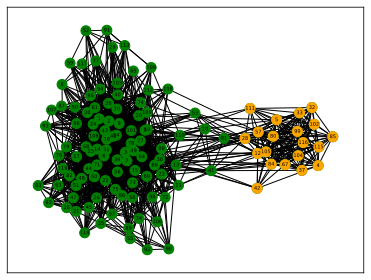

In [28]:
c1, c2 = spectral_clustering_sc2(G0)

pos = nx.spring_layout(G0)

nx.draw_networkx_edges(G0, pos)
nx.draw_networkx_nodes(G0, pos, nodelist=G0.nodes, node_color="green",node_size=100)
nx.draw_networkx_nodes(G0, pos, nodelist=c2, node_color="orange",node_size=100)
nx.draw_networkx_labels(G0, pos, font_size=5)

100%|██████████| 50/50 [3:00:52<00:00, 217.05s/it]  


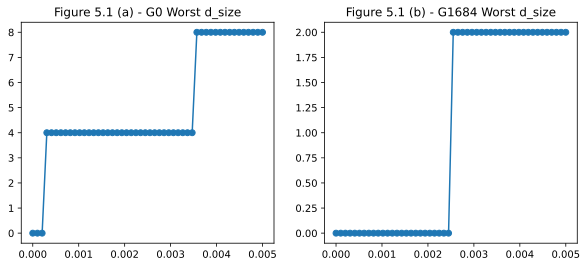

In [15]:
p_small = np.linspace(0, 0.005, 50)
worst0_small, _ = run_experiment(G0, p_small, num_trials=100)
worst1684_small, _ = run_experiment(G1684, p_small, num_trials=100)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(p_small, worst0_small, 'o-')
plt.title("Figure 5.1 (a) - G0 Worst d_size")
plt.subplot(1, 2, 2)
plt.plot(p_small, worst1684_small, 'o-')
plt.title("Figure 5.1 (b) - G1684 Worst d_size")
plt.savefig("Figure 5.1.svg", format="svg")
plt.show()

100%|██████████| 50/50 [3:50:58<00:00, 277.17s/it]  


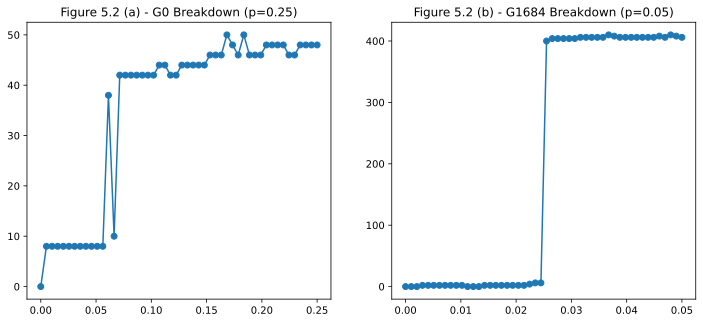

In [33]:
p_large_0 = np.linspace(0, 0.25, 50)
worst0_large, avg0_large = run_experiment(G0, p_large_0, num_trials=100)

# Cho G1684 (Figure 5.2b)
p_large_1684 = np.linspace(0, 0.05, 50)
worst1684_large, avg1684_large = run_experiment(G1684, p_large_1684, num_trials=100)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(p_large_0, worst0_large, 'o-')
plt.title("Figure 5.2 (a) - G0 Breakdown (p=0.25)")
plt.subplot(1, 2, 2)
plt.plot(p_large_1684, worst1684_large, 'o-')
plt.title("Figure 5.2 (b) - G1684 Breakdown (p=0.05)")
plt.savefig("Figure 5.2.svg", format="svg")
plt.show()

100%|██████████| 50/50 [10:57<00:00, 13.16s/it]


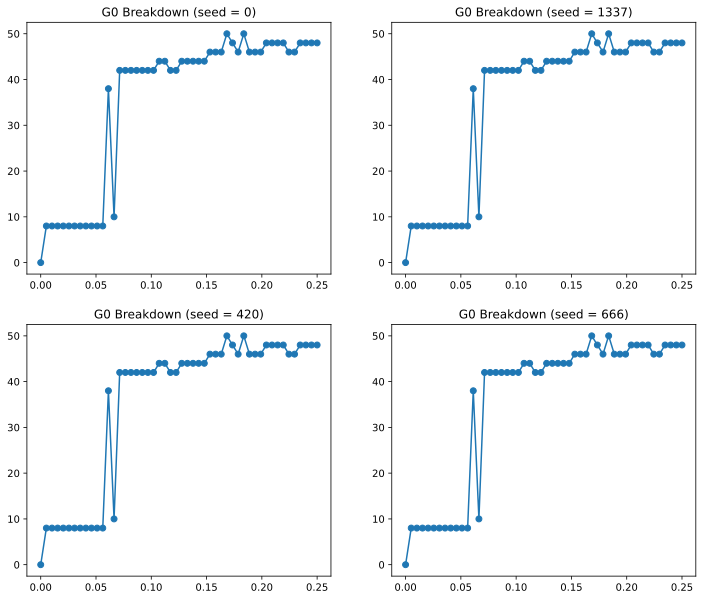

In [34]:
plt.figure(figsize=(12, 10))
p_large_0 = np.linspace(0, 0.25, 50)

worst_large = [0] * 4
avg_large = [0] * 4

for i, seed in enumerate([0, 1337, 420, 666]):
    random.seed(seed)
    np.random.seed(seed)

    worst_large[i], _ = run_experiment(G0, p_large_0, num_trials=100)

    plt.subplot(2, 2, i + 1)
    plt.plot(p_large_0, worst_large[i], 'o-')
    plt.title(f"G0 Breakdown (seed = {seed})")
plt.savefig("Figure 5.2 seeds.svg", format="svg")
plt.show()

100%|██████████| 20/20 [1:53:13<00:00, 339.66s/it]


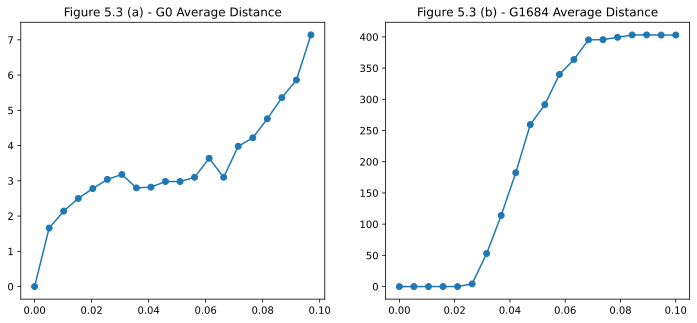

In [32]:
p_large_1684 = np.linspace(0, 0.10, 20)
worst1684_large, avg1684_large = run_experiment(G1684, p_large_1684, num_trials=100)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(p_large_0[:20], avg0_large[:20], 'o-') # Phóng to vùng p < 0.1
plt.title("Figure 5.3 (a) - G0 Average Distance")
plt.subplot(1, 2, 2)
plt.plot(p_large_1684, avg1684_large, 'o-')
plt.title("Figure 5.3 (b) - G1684 Average Distance")
plt.savefig("Figure 5.3.svg", format="svg")
plt.show()